# Univariate forecasting with `numpyro_forecast`

This notebook ports the blog post [**Univariate time series forecasting with NumPyro**](https://juanitorduz.github.io/numpyro_forecasting-univariate/) (itself a port of Pyro's [forecasting tutorial](https://pyro.ai/examples/forecasting_i.html)) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. We forecast **weekly BART ridership** with a random-walk local level, Fourier seasonality and a Student-T likelihood, fit by SVI, and evaluate with CRPS.

Instead of hand-writing the NumPyro model and a bespoke prediction loop, we subclass `numpyro_forecast.forecaster.ForecastingModel` and let `Forecaster` handle the *fit-once / forecast-any-horizon* mechanics (the forecast horizon is drawn from separate `_future` latent sites, so the variational guide is never resized).

Visualizations use **ArviZ >= 1.0** (`az.hdi` + `fill_between` for the multi-band predictive checks, `az.plot_lm` for the forecast-vs-observed panel).

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism (rather than re-running the guide over the full covariates), and the seasonal design uses `fourier_features`, an equivalent Fourier basis.

## Prepare notebook

In [1]:
import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import xarray as xr
from jax import random
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.evaluate import eval_crps
from numpyro_forecast.forecaster import Forecaster, ForecastingModel
from numpyro_forecast.typing import Array
from numpyro_forecast.util import fourier_features

numpyro.set_host_device_count(n=4)
plt.rcParams["figure.figsize"] = (10, 4)

rng_key = random.PRNGKey(seed=42)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

We use total **weekly** BART ridership on the log scale (hourly counts summed over all origin-destination pairs and aggregated into non-overlapping weeks). Time is at axis `-2` and there is a single observation dimension at axis `-1`, matching the package convention.

data shape: (469, 1)


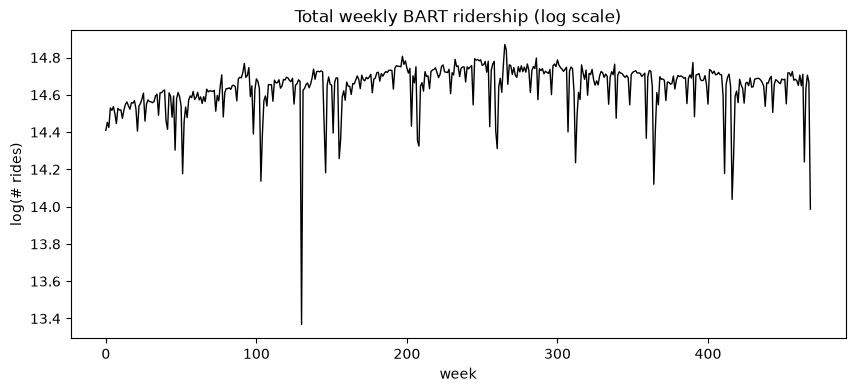

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

fig, ax = plt.subplots()
ax.plot(np.asarray(data[:, 0]), color="black", lw=1)
ax.set(
    title="Total weekly BART ridership (log scale)",
    xlabel="week",
    ylabel="log(# rides)",
);

## Train-test split

We hold out the last `52` weeks (one year) for testing and train on the preceding `417` weeks.

train: (417, 1) test: (52, 1)


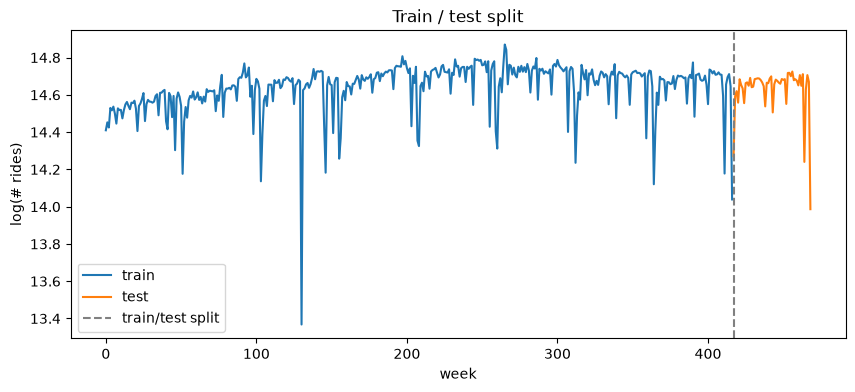

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

We capture the annual cycle with a **Fourier** design matrix of `26` harmonics (52 sine/cosine columns) at a period of `365.25 / 7` weeks. This spans the same subspace as the blog's `periodic_features`, so with the `Normal(0, 0.1)` weight prior the regression is equivalent.

covariates shape: (469, 52)


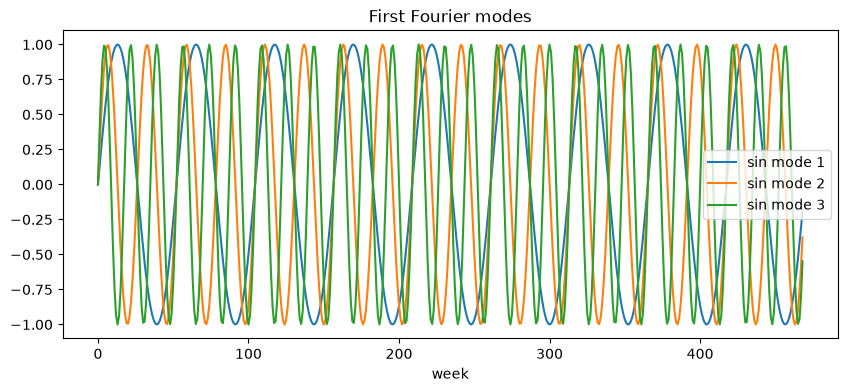

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

fig, ax = plt.subplots()
for k in range(3):
    ax.plot(np.asarray(covariates[:, k]), label=f"sin mode {k + 1}")
ax.legend()
ax.set(title="First Fourier modes", xlabel="week");

## Model specification

The mean is a random-walk local level plus a Fourier regression, with a heavy-tailed Student-T likelihood:

$$
\mu_t = \text{bias} + \ell_t + w^\top x_t,
\qquad \ell_t = \ell_{t-1} + \delta_t,
\qquad \delta_t \sim \mathcal{N}(0, \sigma_\text{drift}),
$$
$$
y_t \sim \text{StudentT}(\nu, \mu_t, \sigma).
$$

We subclass `ForecastingModel`: the random-walk level is the cumulative sum of `drift` sampled with `self.time_series(...)` (equivalent to the blog's `scan`), and `self.predict(...)` registers the (zero-centered) Student-T noise. A `LocScaleReparam` improves the SVI geometry of the drift.

In [5]:
class UnivariateForecaster(ForecastingModel):
    """Local level + Fourier regression with Student-T observations."""

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the univariate forecasting model."""
        num_features = covariates.shape[-1]

        bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
        weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
        sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
        centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

        drift = self.time_series(
            "drift",
            lambda: dist.Normal(0.0, drift_scale),
            reparam=LocScaleReparam(centered=centered),
        )
        level = jnp.cumsum(drift, axis=-2)
        regression = (weight * covariates).sum(axis=-1, keepdims=True)
        prediction = level + bias + regression

        self.predict(dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

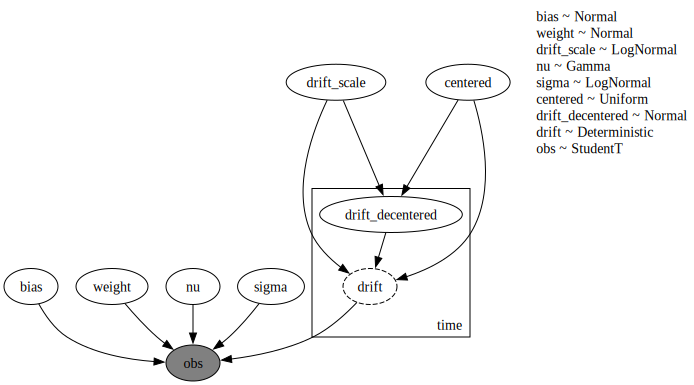

In [6]:
numpyro.render_model(
    UnivariateForecaster(),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

We draw from the prior over the training window (`data=None` so the horizon is zero and the `obs` site spans the train period) and overlay the 50% and 94% HDI bands on the observed data.

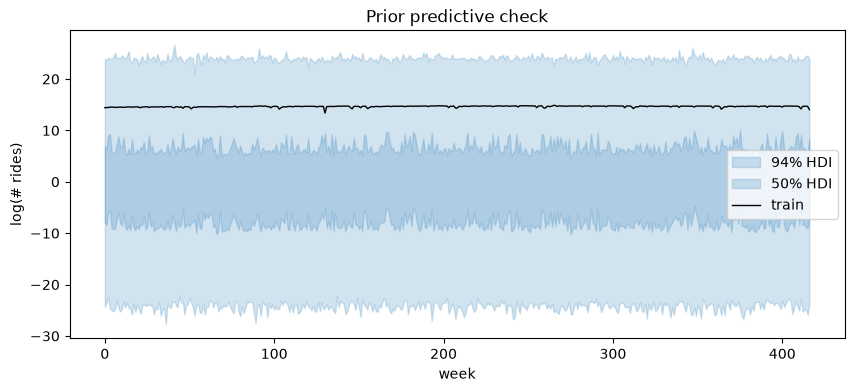

In [7]:
def hdi_bounds(samples: Array, prob: float) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(samples)
    da = xr.DataArray(arr[None], dims=["chain", "draw", "time"])
    band = az.hdi(da, prob=prob)
    return band.sel(ci_bound="lower").values, band.sel(ci_bound="upper").values


prior_predictive = Predictive(UnivariateForecaster(), num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

fig, ax = plt.subplots()
for prob in [0.94, 0.5]:
    lower, upper = hdi_bounds(prior_obs, prob)
    ax.fill_between(
        time_train,
        lower,
        upper,
        color="C0",
        alpha=0.2,
        label=f"{prob * 100:.0f}% HDI",
    )
ax.plot(time_train, np.asarray(y_train[:, 0]), color="black", lw=1, label="train")
ax.legend()
ax.set(title="Prior predictive check", xlabel="week", ylabel="log(# rides)");

## Inference with SVI

`Forecaster` fits the model with stochastic variational inference (an `AutoNormal` guide and `Adam`), exposing the fitted `guide`, `params` and the ELBO `losses`.

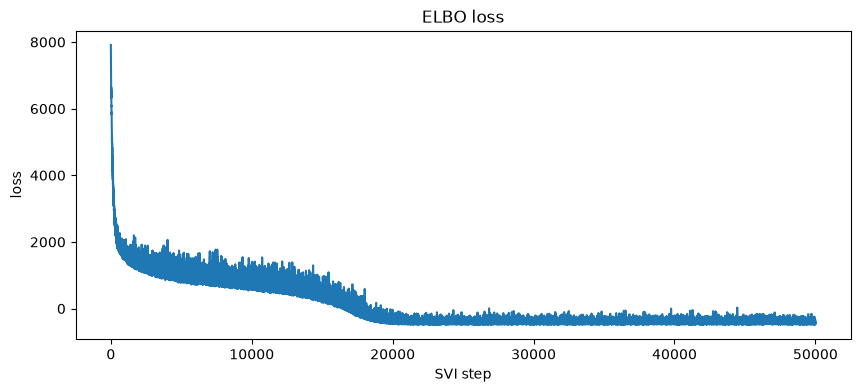

In [8]:
rng_key, rng_subkey = random.split(rng_key)
model = UnivariateForecaster()
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.005),
    num_steps=50_000,
    rng_key=rng_subkey,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We draw the **in-sample** posterior predictive over the train window (the horizon is zero, so the guide is not resized) and the **forecast** over the test horizon with `forecaster(...)` (which continues the level from its inferred end and draws the random-walk increments from the prior). We evaluate both with CRPS.

In [9]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)

# In-sample posterior predictive over the training window.
posterior_samples = forecaster.guide.sample_posterior(
    key_post, forecaster.params, sample_shape=(5_000,)
)
train_pp = Predictive(model, posterior_samples=posterior_samples, return_sites=["obs"])(
    key_pp, covariates_train
)["obs"]

# Forecast over the test horizon.
forecast = forecaster(y_train, covariates, num_samples=5_000, rng_key=key_fc)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.0283
Test CRPS:  0.0349


## Forecast visualization

The combined view shows the in-sample posterior predictive (blue) and the forecast (orange), each with 50% and 94% HDI bands.

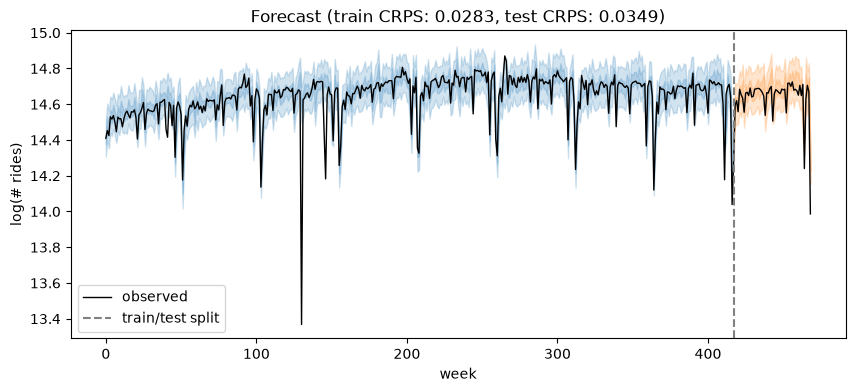

In [10]:
train_obs = train_pp[..., 0]
forecast_obs = forecast[..., 0]

fig, ax = plt.subplots()
for prob in [0.94, 0.5]:
    lower, upper = hdi_bounds(train_obs, prob)
    ax.fill_between(time_train, lower, upper, color="C0", alpha=0.2)
    lower, upper = hdi_bounds(forecast_obs, prob)
    ax.fill_between(time_test, lower, upper, color="C1", alpha=0.2)
ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(
    title=f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    xlabel="week",
    ylabel="log(# rides)",
);

Finally, an ArviZ `plot_lm` panel focused on the test horizon (forecast HDI band vs. the held-out observations).

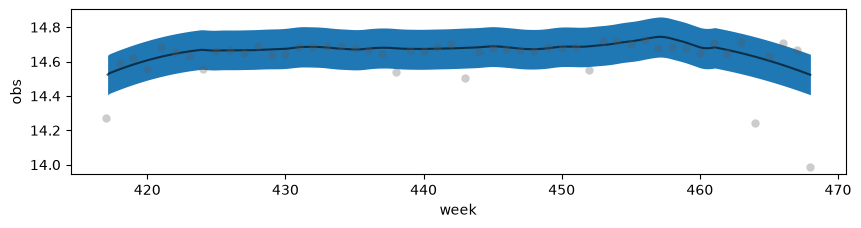

In [11]:
idata = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(y_test[:, 0])},
        "constant_data": {"week": time_test.astype(float)},
    },
    coords={"time": time_test.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
az.plot_lm(idata, y="obs", x="week", ci_kind="hdi", ci_prob=0.94);